# Edge-ML Data Processing and Feature Engineering
This notebook loads datasets from Edge-ML, filters and preprocesses accelerator data (including trimming transitional pocket movements), applies rolling-window aggregations to extract statistical features, and visualizes the structured metrics across multiple axes.

### 1. Import Libraries and Load Environment Variables

In [1]:
import os 
from dotenv import load_dotenv
from edgeml import DatasetReceiver, Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# # Get API Keys
load_dotenv()
write_key = os.getenv("EDGE_WRITE_KEY")
read_key = os.getenv("EDGE_READ_KEY")

### 2. Initialize Edge-ML Receiver

In [2]:
# Uses Read- and Write-Key!
receiver = DatasetReceiver(
    backendURL="https://app.edge-ml.org",
    readKey=read_key,
    writeKey=write_key
)


### 3. Helper Functions for Dataset Discovery and Querying

In [3]:
# Gather all Datasets that have a certain name
def gather(datasets: list[Dataset], name: str):
    return [ds for ds in datasets if getName(ds) == name]

def getParticipant(ds: Dataset):
    participant = ds.metaData.get("participantId") or ds.metaData.get("participant")
    return participant if participant is not None else None
    
def getWithParticipant(datasets: list[Dataset]): # type: ignore
    return [ds for ds in datasets if getParticipant(ds) != None]

# Gather own Datasets that have a certain name
def gatherOwn(datasets: list[Dataset], name: str):
    return [ds for ds in getOwn(datasets=datasets) if getName(ds) == name]    

# Get the label of the dataset (e.g. "swimming")
def getName(ds: Dataset):
    if ds.labelings == [] or ds.labelings == None:
        return ""
    return ds.labelings[0].labels[-1].name.lower()

# Get the dataset that I have created
def getOwn(datasets: list[Dataset]):
    return [ds for ds in datasets if ds.name.startswith("uoihp")]    

### 4. Fetch Label-Specific Datasets

In [4]:
datasets = receiver.datasets
datasets_with_participant = getWithParticipant(datasets=datasets) 
print(f"Number of datasets: {len(datasets)}")
print(f"Number of datasets with pariticapant metadata: {len(datasets_with_participant)}")

# sitting
sitting_ds = gather(datasets_with_participant, "sitting")
print(f"Number of datasets with sitting: {len(sitting_ds)}")

walking_ds = gather(datasets_with_participant, "walking")
print(f"Number of datasets with walking: {len(walking_ds)}")

running_ds = gather(datasets_with_participant, "running")
print(f"Number of datasets with running: {len(running_ds)}")

stairs_ds  = gather(datasets_with_participant, "stairs")
print(f"Number of datasets with stairs: {len(stairs_ds)}")

standing_ds  = gather(datasets_with_participant, "standing")
print(f"Number of datasets with standing: {len(standing_ds)}")

participant_label = {}

def mapParticipant(datasets: list[Dataset], participant_label: dict[str, int]):
  for ds in datasets:
    participant = getParticipant(ds)
    if participant not in participant_label:
      participant_label[participant] = len(participant_label)

mapParticipant(sitting_ds, participant_label)
mapParticipant(walking_ds, participant_label)
mapParticipant(running_ds, participant_label)
mapParticipant(stairs_ds, participant_label)

print(participant_label)

Number of datasets: 114
Number of datasets with pariticapant metadata: 57
Number of datasets with sitting: 12
Number of datasets with walking: 17
Number of datasets with running: 4
Number of datasets with stairs: 4
Number of datasets with standing: 0
{'Till Hoffmann': 0, 'ukjvp_s1': 1, 'ukjvp_s2': 2, '01': 3, 'testify': 4, 'P001': 5, 'ukjvp_s3': 6, 'ukjvp_s4': 7, 'gh': 8, 'zh': 9, 'jh': 10, 'ukjvp_w1': 11, 'ukjvp_w2': 12, 'ukjvp_w3': 13, 'ukjvp_w4': 14, 'ukjvp_w5': 15, 'ukjvp_w7': 16, 'ukjvp_w8': 17, 'ukjvp_w9': 18, 'ukjvp_w10': 19, 'ukjvp_walkin_wm': 20, 'ukjvp_r1': 21, 'ukjvp_r2': 22, 'ukjvp_r3': 23, 'ukjvp_r4': 24}


### 5. Data Transformation and Edge Trimming Functions

In [5]:
# Resample data because of different sample rates
# Convert datasets into one dataframe per activity
import numpy as np
import pandas as pd

def csv_dfs_to_df_with_trimmed_edges(df_list, activity_list):
    frames = []

    for (original_df, activity) in zip(df_list, activity_list):
        # Create a copy so we don't accidentally modify the original variable
        df = original_df.copy()

        # Ensure the columns match your required features
        df = df[
            ["time", "sensor_accX", "sensor_accY", "sensor_accZ", "subject"]
        ]

        df = df.rename(columns={
            "sensor_accX": "accX",
            "sensor_accY": "accY",
            "sensor_accZ": "accZ"
        })

        df = df.rename(columns={
            "sensor_acceleration.x": "accX",
            "sensor_acceleration.y": "accY",
            "sensor_acceleration.z": "accZ"
        })

        # add new feature
        # 3D acceleration amplitude
        # ---------------------------------- 
        df["accM"] = np.sqrt(
            df["accX"]**2 + 
            df["accY"]**2 + 
            df["accZ"]**2
        )
        # ---------------------------------- 


        df["time"] = pd.to_datetime(df["time"], unit="ms")
        
        df = df.sort_values("time")        
        start_time = df["time"].min() + pd.Timedelta(seconds=2)
        end_time = df["time"].max() - pd.Timedelta(seconds=2)
        
        # Keep only the data in the middle
        df = df[(df["time"] >= start_time) & (df["time"] <= end_time)]

        df["activity"] = activity
        frames.append(df)

    return pd.concat(frames, ignore_index=True)

def datasets_to_df_with_trimmed_edges(datasets: list[Dataset], activity: str, participant_label):
    frames = []

    for ds in datasets:
        # Create a copy so we don't accidentally modify the original variable
        ds.loadData()
        df = pd.DataFrame(ds.data)


        # Find which set of columns actually exists in this dataset
        if all(col in df.columns for col in ["accX", "accY", "accZ"]):
            acc_cols = ["accX", "accY", "accZ"]
        elif all(col in df.columns for col in ["acceleration.x", "acceleration.y", "acceleration.z"]):
            acc_cols = ["acceleration.x", "acceleration.y", "acceleration.z"]
        elif all(col in df.columns for col in ["sensor_acc_X", "sensor_acc_Y", "sensor_acc_Z"]):
            acc_cols = ["acc_X", "acc_Y", "acc_Z"]
        else:
            raise KeyError(f"Could not find a matching accelerometer column format in this dataset.\n DataFrame: {df}")

        # Ensure the columns match your required features
        df = df[["time"] + acc_cols]

        df = df.rename(columns={
            "sensor_accX": "accX",
            "sensor_accY": "accY",
            "sensor_accZ": "accZ"
        })

        df = df.rename(columns={
            "acceleration.x": "accX",
            "acceleration.y": "accY",
            "acceleration.z": "accZ"
        })

        df = df.rename(columns={
            "acc_X": "accX",
            "acc_Y": "accY",
            "acc_Z": "accZ"
        })

        # add new feature
        # 3D acceleration amplitude
        # ---------------------------------- 
        df["accM"] = np.sqrt(
            df["accX"]**2 + 
            df["accY"]**2 + 
            df["accZ"]**2
        )
        # ---------------------------------- 


        df["time"] = pd.to_datetime(df["time"], unit="ms")
        
        df = df.sort_values("time")        
        start_time = df["time"].min() + pd.Timedelta(seconds=2)
        end_time = df["time"].max() - pd.Timedelta(seconds=2)
        
        # Keep only the data in the middle
        df = df[(df["time"] >= start_time) & (df["time"] <= end_time)]

        df["activity"] = activity
        df["subject"]  = participant_label[getParticipant(ds)]
        frames.append(df)

    return pd.concat(frames, ignore_index=True)

In [6]:
sitting_df = datasets_to_df_with_trimmed_edges(sitting_ds, "sitting", participant_label)
walking_df = datasets_to_df_with_trimmed_edges(walking_ds, "walking", participant_label)
running_df = datasets_to_df_with_trimmed_edges(running_ds, "running", participant_label)
stairs_df  = datasets_to_df_with_trimmed_edges(stairs_ds,  "stairs",  participant_label)

big_df = pd.concat([sitting_df, walking_df, running_df, stairs_df], ignore_index=True)

big_df = big_df.sample(frac=1, random_state=42).reset_index(drop=True).dropna()


### 6. Process Activity Data and Concatenate

In [7]:

# Load each CSV and explicitly add a label column
df_sit1    = pd.read_csv("data/sitting1.csv")
df_sit1["subject"] = 0 
df_sit2    = pd.read_csv("data/sitting2.csv")
df_sit2["subject"] = 1 
df_sit3    = pd.read_csv("data/sitting3.csv")
df_sit3["subject"] = 2 
df_sit4    = pd.read_csv("data/sitting4.csv")
df_sit4["subject"] = 3

df_walk1   = pd.read_csv("data/walking1.csv")
df_walk1["subject"] = 0 
df_walk2   = pd.read_csv("data/walking2.csv")
df_walk2["subject"] = 1 
df_walk3   = pd.read_csv("data/walking3.csv")
df_walk3["subject"] = 2
df_walk4   = pd.read_csv("data/walking4.csv")
df_walk4["subject"] = 3 

df_stairs1 = pd.read_csv("data/stairs1.csv")
df_stairs1["subject"] = 0 
df_stairs2 = pd.read_csv("data/stairs2.csv")
df_stairs2["subject"] = 1 
df_stairs3 = pd.read_csv("data/stairs3.csv")
df_stairs3["subject"] = 2 
df_stairs4 = pd.read_csv("data/stairs4.csv")
df_stairs4["subject"] = 3


# Combine all of them into a single DataFrame
df = csv_dfs_to_df_with_trimmed_edges(
  [
    # subject 0 is gonna be test subsject
    # df_sit1, df_walk1, df_stairs1,
    df_sit2, df_walk2, df_stairs2,
    df_sit3, df_walk3, df_stairs3,
    df_sit4, df_walk4, df_stairs4
  ],
  [
    # subject 0 is gonna be test subsject
    # "sitting", "walking", "stairs",
    "sitting", "walking", "stairs",
    "sitting", "walking", "stairs",
    "sitting", "walking", "stairs"
])

df_test = csv_dfs_to_df_with_trimmed_edges(
  [
    # subject 0 is gonna be test subsject
    df_sit1, df_walk1, df_stairs1
  ],
  [
    # subject 0 is gonna be test subsject
    "sitting", "walking", "stairs"
])


# Augment data (everything has the same sensor orientation and positioning)
def augment_random_rotation_3d(df):
    """Rotates accX, accY, accZ by completely random angles across all 3 axes."""
    # Initialize the random number generator
    rng = np.random.default_rng(42)
    
    # Pick 3 completely random angles between -180 and +180 degrees using rng
    alpha = np.radians(rng.uniform(-180, 180)) # Rotation around X
    beta  = np.radians(rng.uniform(-180, 180)) # Rotation around Y
    gamma = np.radians(rng.uniform(-180, 180)) # Rotation around Z

    # Rotation matrix for X-axis
    Rx = np.array([[1, 0, 0],
                   [0, np.cos(alpha), -np.sin(alpha)],
                   [0, np.sin(alpha), np.cos(alpha)]])
    
    # Rotation matrix for Y-axis
    Ry = np.array([[np.cos(beta), 0, np.sin(beta)],
                   [0, 1, 0],
                   [-np.sin(beta), 0, np.cos(beta)]])
    
    # Rotation matrix for Z-axis
    Rz = np.array([[np.cos(gamma), -np.sin(gamma), 0],
                   [np.sin(gamma), np.cos(gamma), 0],
                   [0, 0, 1]])
    
    # Total 3D Rotation Matrix
    R = np.dot(Rz, np.dot(Ry, Rx))

    # Apply to vectors
    vectors = df[["accX", "accY", "accZ"]].values
    rotated_vectors = np.dot(vectors, R.T)

    df_rotated = df.copy()
    df_rotated[["accX", "accY", "accZ"]] = rotated_vectors
    return df_rotated

def augment_random_jitter(df):
    """Adds a completely randomized intensity of Gaussian noise."""
    # Initialize the random number generator
    rng = np.random.default_rng(42)
    
    # Randomly pick a noise standard deviation between 0.01 (tiny) and 0.25 (heavy)
    random_noise_level = rng.uniform(0.01, 0.25)
    
    df_jittered = df.copy()
    for col in ["accX", "accY", "accZ"]:
        noise = np.random.normal(0, random_noise_level, size=len(df))
        df_jittered[col] = df_jittered[col] + noise
    return df_jittered

df_rotated1  = augment_random_rotation_3d(df)
df_rotated2  = augment_random_rotation_3d(df)
df_rotated3  = augment_random_rotation_3d(df)

df_jitter1 = augment_random_jitter(df)
df_jitter2 = augment_random_jitter(df)
df_jitter3 = augment_random_jitter(df)

df_rotated = [
  df_rotated1,
  df_rotated2,
  df_rotated3,
]

df_all_rotated = pd.concat(df_rotated, ignore_index=True)

df_jittered = [
  df_jitter1,
  df_jitter2,
  df_jitter3
]

df_all_jittered = pd.concat(df_jittered, ignore_index=True)

df_rotated_jittered  = augment_random_rotation_3d(df_all_jittered)

# Merge augmented data and test data
df = pd.concat(
  [
    # Debug: for Later if more data is needed
    # df_all_rotated, 
    # df_all_jittered, 
    # df_rotated_jittered, 
    df,
    df_test
  ], 
  ignore_index=True
)

# Shuffle the data (optional, but highly recommended for ML training)
df = df.sample(frac=1, random_state=42).reset_index(drop=True).dropna()

# RENAME LATER BIG DATA SET INSERTED
df = big_df

print("Combined Dataset Info:")
print(df.info())
print("\nLabel Breakdown:")
print(df["activity"].value_counts())

print(df.head())


Combined Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 77996 entries, 0 to 78514
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   time      77996 non-null  datetime64[ns]
 1   accX      77996 non-null  float32       
 2   accY      77996 non-null  float32       
 3   accZ      77996 non-null  float32       
 4   accM      77996 non-null  float32       
 5   activity  77996 non-null  object        
 6   subject   77996 non-null  int64         
dtypes: datetime64[ns](1), float32(4), int64(1), object(1)
memory usage: 3.6+ MB
None

Label Breakdown:
activity
walking    48171
sitting    18678
running     7372
stairs      3775
Name: count, dtype: int64
                     time  accX  accY  accZ      accM activity  subject
0 2026-06-02 11:14:06.166 -2.16  8.84 -1.04  9.159301  walking        3
1 2026-06-25 09:10:43.991 -0.30  0.50  9.70  9.717509  sitting       10
2 2026-06-03 09:09:23.629 -8.59  4.51

### 7. Feature Extraction Using Rolling Windows

In [8]:
# 1. Set the time as the index and sort it chronologically
df_sorted = df.set_index("time").sort_index()

# 2. Group by activity, apply the rolling window, and aggregate
df_windowed = (
    df_sorted.groupby(["activity", "subject"])
      .rolling(window="1s")  # 'on="time"' is no longer needed since it's the index
      .agg(["mean", "std"])
      .dropna()
      .reset_index()          # Brings 'activity' and 'time' back as normal columns
)

# 3. Clean up MultiIndex column names (e.g., 'accX_mean')
df_windowed.columns = [
    f"{col[0]}_{col[1]}" if isinstance(col, tuple) and col[1] else col[0]
    for col in df_windowed.columns
 ]

# Roll: rotation around X-axis
df_windowed["rollX_deg"] = np.degrees(
    np.arctan2(df_windowed["accY_mean"], df_windowed["accZ_mean"])
)

# Roll: rotation around Y-axis
df_windowed["rollY_deg"] = np.degrees(
    np.arctan2(df_windowed["accX_mean"], df_windowed["accZ_mean"])
)

# Roll: rotation around Z-axis
df_windowed["rollZ_deg"] = np.degrees(
    np.arctan2(df_windowed["accX_mean"], df_windowed["accY_mean"])
)


# Pitch: rotation around X-axis
df_windowed["pitchX_deg"] = np.degrees(
    np.arctan2(
        -df_windowed["accZ_mean"],
        np.sqrt(df_windowed["accX_mean"] ** 2 + df_windowed["accY_mean"] ** 2),
    )
)

# Pitch: rotation around Y-axis
df_windowed["pitchY_deg"] = np.degrees(
    np.arctan2(
        -df_windowed["accX_mean"],
        np.sqrt(df_windowed["accY_mean"] ** 2 + df_windowed["accZ_mean"] ** 2),
    )
)

# Pitch: rotation around Z-axis
df_windowed["pitchZ_deg"] = np.degrees(
    np.arctan2(
        -df_windowed["accY_mean"],
        np.sqrt(df_windowed["accZ_mean"] ** 2 + df_windowed["accX_mean"] ** 2),
    )
)


df_windowed

,activity,subject,time,accX_mean,accX_std,accY_mean,accY_std,accZ_mean,accZ_std,accM_mean,accM_std,rollX_deg,rollY_deg,rollZ_deg,pitchX_deg,pitchY_deg,pitchZ_deg
0,running,21,2026-05-27 17:18:27.185,-2.650000,2.333453,5.200000,0.707107,9.300000,0.848528,11.129661,0.176941,29.211292,-15.904704,-27.004092,-57.889259,13.966576,-28.268486
1,running,21,2026-05-27 17:18:27.201,-2.166667,1.850225,4.566667,1.205543,9.733333,0.960903,11.141930,0.126908,25.134940,-12.549583,-25.382122,-62.556820,11.393895,-24.606294
2,running,21,2026-05-27 17:18:27.218,-2.150000,1.511070,3.550000,2.259056,9.700000,0.787401,10.816376,0.659301,20.101583,-12.497533,-31.200516,-66.835560,11.758092,-19.662195
3,running,21,2026-05-27 17:18:27.235,-2.200000,1.313393,2.800000,2.576820,9.420000,0.925743,10.381568,1.127518,16.554050,-13.145559,-38.157228,-69.292670,12.618499,-16.143132
4,running,21,2026-05-27 17:18:27.251,-1.616667,1.849775,2.516667,2.407004,9.366667,0.838252,10.194302,1.107903,15.039235,-9.792649,-32.716046,-72.289419,9.463406,-14.829831
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77950,walking,20,2026-06-20 22:24:22.764,3.993220,3.924321,-4.923729,4.419601,2.259322,6.179642,10.583949,2.290012,-65.351313,60.499276,140.957412,-19.615538,-36.394574,47.021082
77951,walking,20,2026-06-20 22:24:22.780,3.946667,3.907597,-4.946667,4.385588,2.221667,6.133987,10.514438,2.333491,-65.814008,60.623870,141.415606,-19.344945,-36.047472,47.523742
77952,walking,20,2026-06-20 22:24:22.797,4.144068,3.714801,-4.949153,4.424282,2.483051,5.950345,10.474570,2.414540,-63.356516,59.070718,140.059593,-21.040195,-36.811780,45.691978
77953,walking,20,2026-06-20 22:24:22.814,4.254237,3.530767,-4.954237,4.425098,2.579661,5.835586,10.403846,2.478560,-62.494101,58.768446,139.347089,-21.555898,-37.294400,44.878709


### 8. Prepare Data for Multi-axis Visualization

In [9]:
# 1. Melt the dataframe to long-form
df_melted = df_windowed.melt(
    id_vars=["activity", "time", "subject"],
    value_vars=[
        "accX_mean", "accX_std",
        "accY_mean", "accY_std",
        "accZ_mean", "accZ_std",
        "accM_mean", "accM_std"
        # ,
        # "rollX_deg", "pitchX_deg",
        # "rollY_deg", "pitchY_deg",
        # "rollZ_deg", "pitchZ_deg"
    ],
    var_name="Sensor_Metric",
    value_name="Value"
)

# 2. Split the names into separate 'Axis' and 'Metric' columns
df_melted["Axis"] = df_melted["Sensor_Metric"].apply(lambda x: x.split("_")[0].replace("acc", ""))
df_melted["Metric"] = df_melted["Sensor_Metric"].apply(lambda x: x.split("_")[1])

# Check right now if 'Metric' actually exists and has data
print(df_melted.head())


  activity                    time  subject Sensor_Metric     Value Axis  \
0  running 2026-05-27 17:18:27.185       21     accX_mean -2.650000    X   
1  running 2026-05-27 17:18:27.201       21     accX_mean -2.166667    X   
2  running 2026-05-27 17:18:27.218       21     accX_mean -2.150000    X   
3  running 2026-05-27 17:18:27.235       21     accX_mean -2.200000    X   
4  running 2026-05-27 17:18:27.251       21     accX_mean -1.616667    X   

  Metric  
0   mean  
1   mean  
2   mean  
3   mean  
4   mean  


### 9. Plot Structural Metrics Matrix

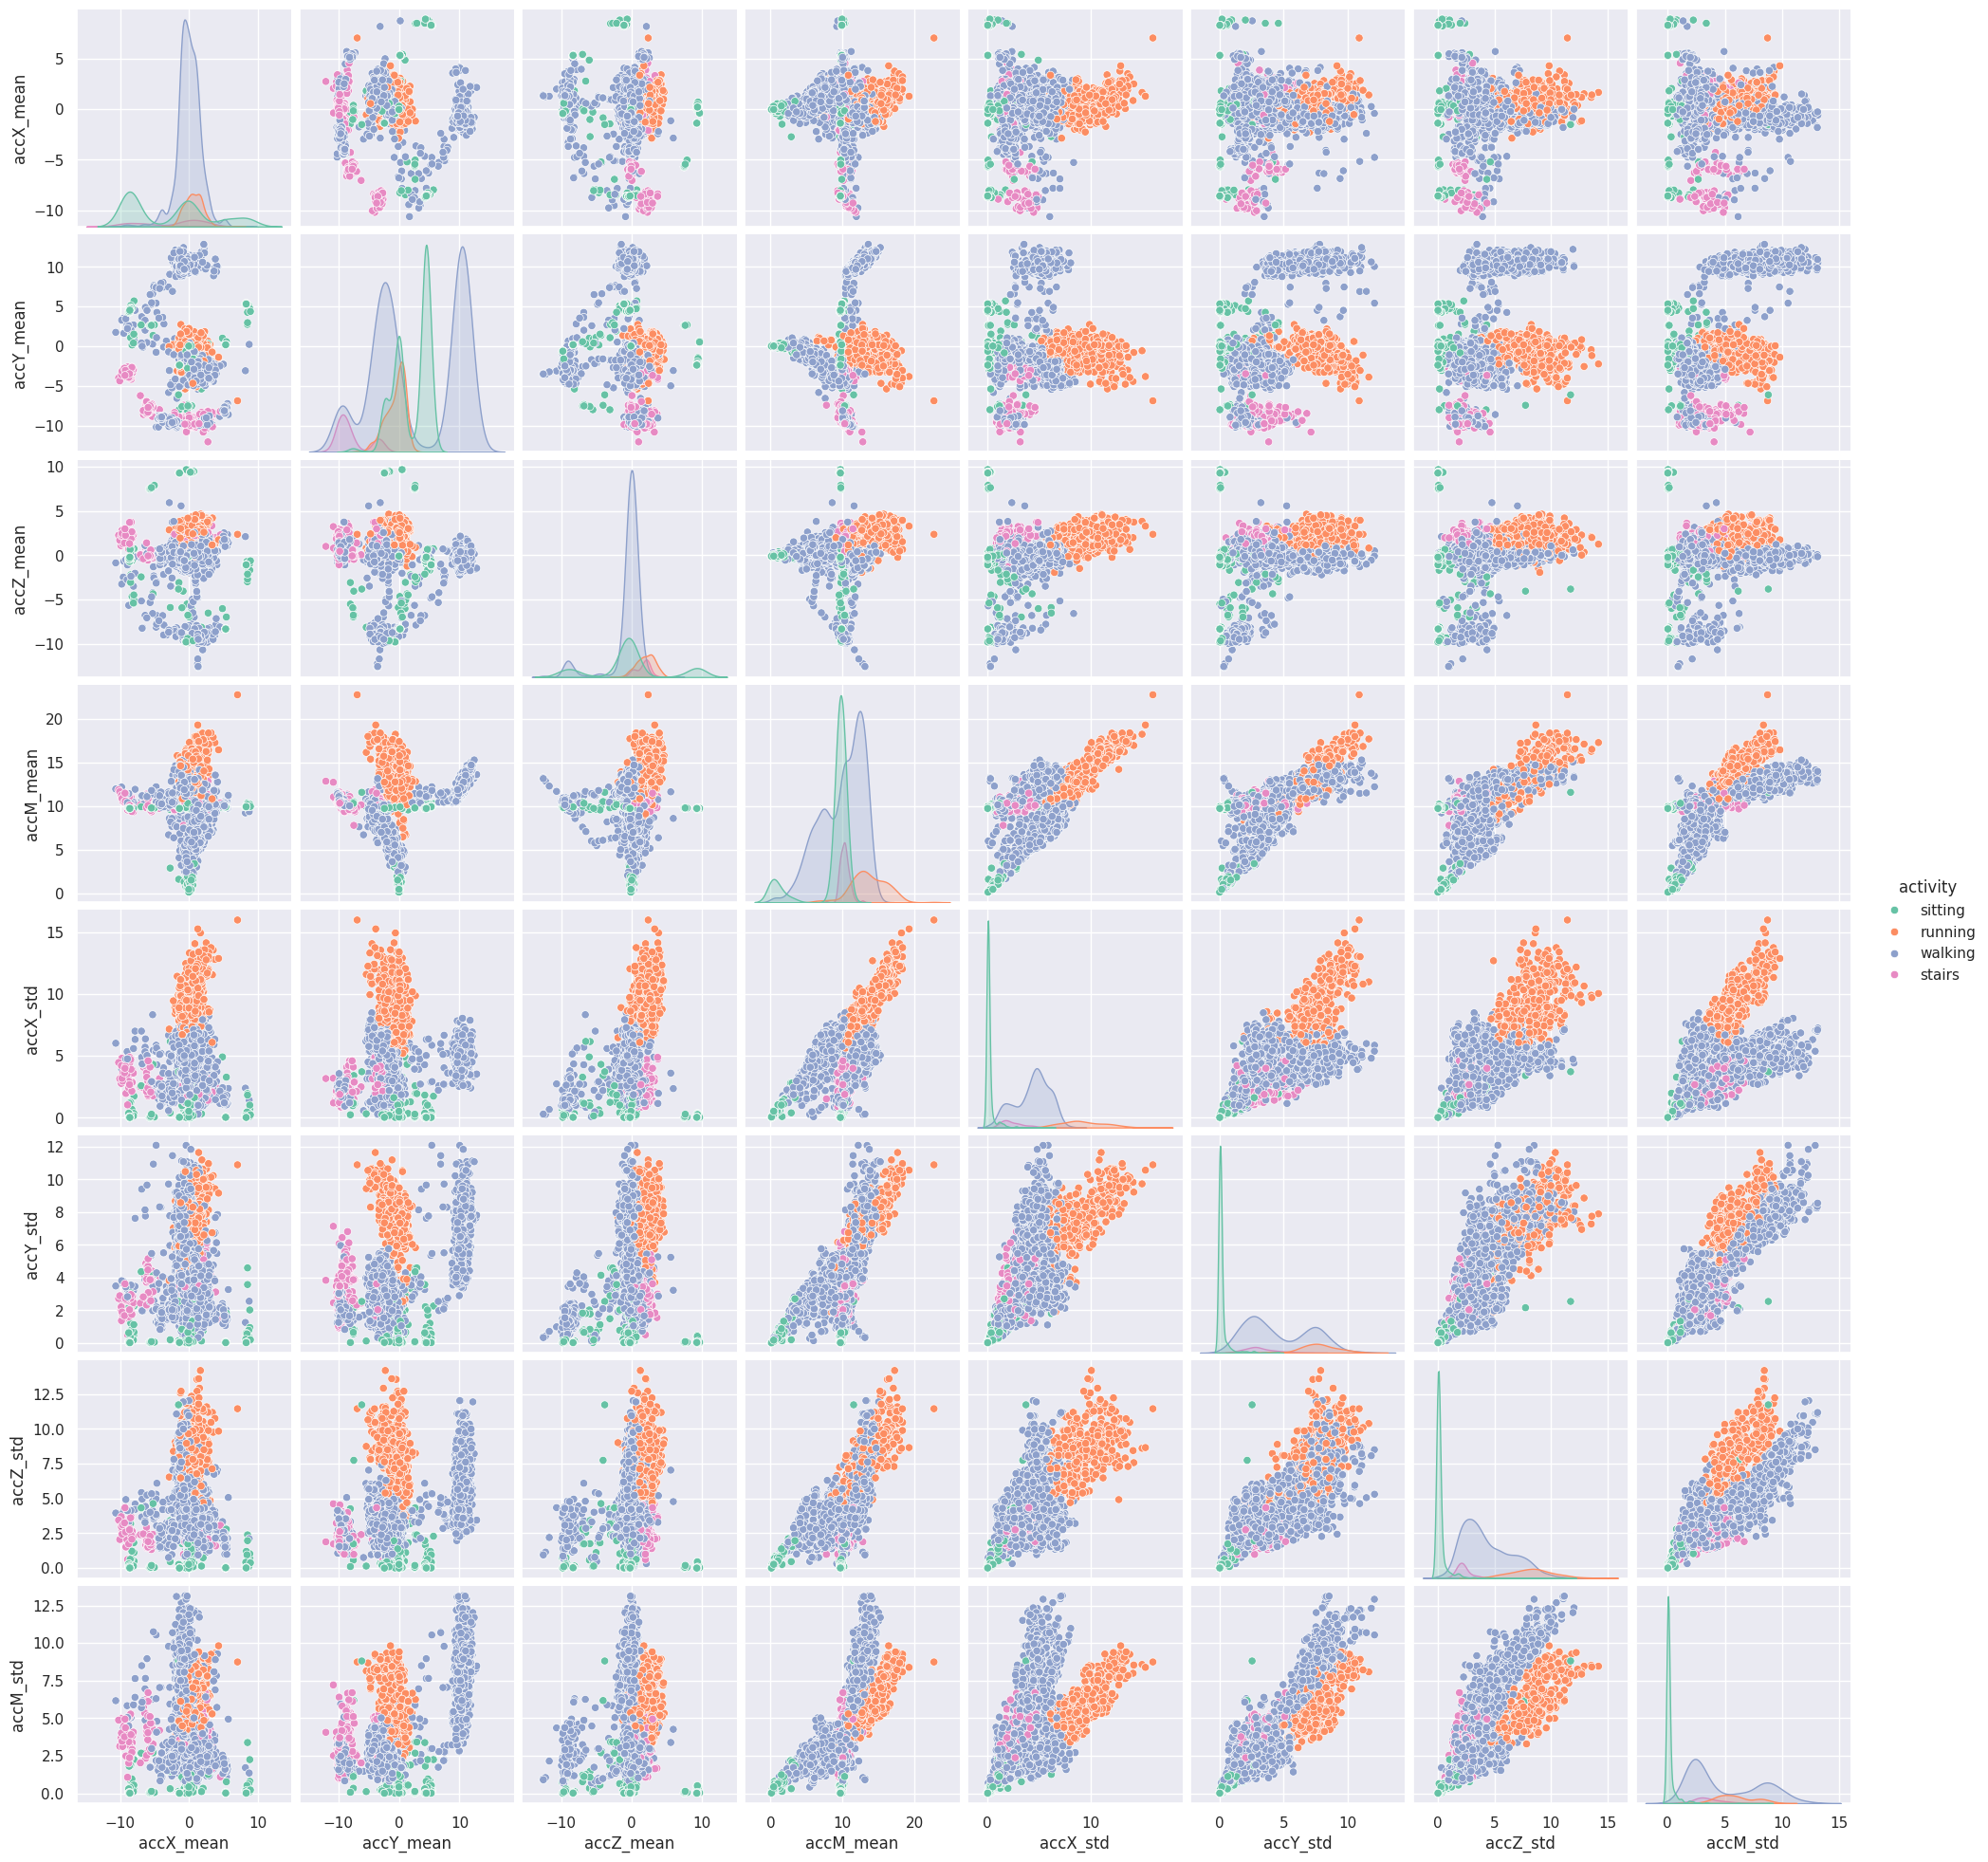

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select only the feature columns you want to compare + the activity label
# (We completely leave out the 'time' column here)
feature_cols = [
    "accX_mean", "accY_mean", "accZ_mean", "accM_mean",
    "accX_std", "accY_std", "accZ_std", "accM_std",
    # "rollX_deg",
    # "rollY_deg",
    # "rollZ_deg",
    # "pitchX_deg",
    # "pitchY_deg",
    # "pitchZ_deg",
    "activity"
]

df_features = df_windowed[feature_cols]

df_small = df_windowed.sample(frac=0.05, random_state=42)
df_small_features = df_small[feature_cols]

feature_cols = [
    "accX_mean", "accY_mean", "accZ_mean", "accM_mean",
    "accX_std", "accY_std", "accZ_std", "accM_std"
    # ,
    # "rollX_deg",
    # "rollY_deg",
    # "rollZ_deg",
    # "pitchX_deg",
    # "pitchY_deg",
    # "pitchZ_deg",
]

# 2. Set the theme
sns.set_theme(style="darkgrid")

# 3. Create the pairplot matrix
# 'hue' colors the points by sitting, walking, stairs
# 'kind="scatter"' ensures they show up as independent data points
g = sns.pairplot(
    data=df_small_features,
    vars=feature_cols,
    hue="activity", 
    kind="scatter",
    diag_kind="kde", # Shows the distribution curves on the diagonal
    palette="Set2"
)

# 4. Save and show
plt.savefig("feature_plot.png")
plt.show()

### 10. Train Models

In [19]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.model_selection import LeaveOneGroupOut, KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier


# SMALL DATA BECAUSE BIG DATA TAKES TOO LONG RIGHT NOW
df_windowed = df_small

X = df_windowed[feature_cols].values

groups = df_windowed["subject"].values  # Tracking array for subjects

# Encode our text labels ('walking', 'sitting'...) to 0, 1, 2
le = LabelEncoder()
y = le.fit_transform(df_windowed["activity"])

names = [
    # "Nearest Neighbors",
    # "Linear SVM",
    # "RBF SVM",
    # "Decision Tree",
    # Decided to use random forest
    "Random Forest",
    # "Neural Net",
    # "AdaBoost",
    # "Naive Bayes",
]

classifiers = [
    # KNeighborsClassifier(3),
    # SVC(kernel="linear", C=0.025, random_state=42),
    # SVC(gamma=2, C=1, random_state=42),
    # DecisionTreeClassifier(max_depth=5, random_state=42),
    RandomForestClassifier(
        max_depth=3, n_estimators=10, max_features=5, random_state=42
    ),
    # MLPClassifier(alpha=1, max_iter=1000, random_state=42),
    # AdaBoostClassifier(random_state=42),
    # GaussianNB(),
]

classifiers = list(zip(names, classifiers))

for c in classifiers:
    print("-----------------------------")
    print(f"{c[0]}:")
    print("-----------------------------")
    cvs = cross_val_score(c[1], X, y, groups=groups, cv=LeaveOneGroupOut(), scoring="f1_macro")
    print(f"F1-Score: {cvs.mean()}")

-----------------------------
Random Forest:
-----------------------------
F1-Score: 0.6437839120736455


### 11. PCA

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)

for c in classifiers:
    print("-----------------------------")
    print(f"{c[0]}:")
    print("-----------------------------")
    cvs = cross_val_score(c[1], X_pca, y, groups=groups, cv=LeaveOneGroupOut(), scoring="f1_macro")
    print(f"F1-Score: {cvs.mean()}")


-----------------------------
Random Forest:
-----------------------------
F1-Score: 0.5292125968656323


### 12. RFE

In [21]:
from sklearn.feature_selection import RFE


names = [
    # "Linear SVM",
    # "Decision Tree",
    "Random Forest",
    # "AdaBoost",
]

models = [
    # SVC(kernel="linear", C=0.025, random_state=42),
    # DecisionTreeClassifier(max_depth=5, random_state=42),
    RandomForestClassifier(max_depth=5, n_estimators=10, max_features=5, random_state=42),
    # AdaBoostClassifier(random_state=42),
]

# 1. First, pair them into your list of tuples
classifiers = list(zip(names, models))

feature_cols_arr = np.array(feature_cols)

for c in classifiers:
    rf = c[1]

    rfe = RFE(
        estimator=rf,
        n_features_to_select=4
    )

    rfe.fit(X, y)


    selected_features = feature_cols_arr[rfe.support_]

    X_rfe = df_windowed[selected_features].values 

    print("-----------------------------")
    print(f"{c[0]}:")
    print("-----------------------------")
    cvs = cross_val_score(c[1], X_rfe, y, groups=groups, cv=LeaveOneGroupOut(), scoring="f1_macro")
    print(f"F1-Score: {cvs.mean()}")

    print("Selected features:")
    print(selected_features)


-----------------------------
Random Forest:
-----------------------------
F1-Score: 0.5178470807006534
Selected features:
['accY_mean' 'accZ_mean' 'accX_std' 'accM_std']


### 14. Bayesian Optimization

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

# Kernel allows to make bigger steps than the default kernel
# Just necessary because i set the max to 128 for fun ;)
kernel = Matern(length_scale=20.0, length_scale_bounds=(2.0, 100.0), nu=2.5)

gpr = GaussianProcessRegressor(kernel=kernel, alpha=1e-4, normalize_y=True, n_restarts_optimizer=5)

# Declare Hyperparameter range
X_opt = np.arange(start=1, stop=129, step=1).reshape(-1, 1)

# Keep track of hyperparameter to score
X_score = []

# Hyperparameters
X_bo = []

# Scores
y_bo = []

# initialize first choice of hyperparameter
x_next = 3

for _ in range(10):
  # Add Hyperparameter
  X_bo.append([x_next])

  # Define Model
  clf = RandomForestClassifier(max_depth=5, n_estimators=x_next, max_features=5, random_state=42)
  # Train and Validate Model 
  cvs = cross_val_score(clf, X, y, groups=groups, cv=LeaveOneGroupOut(), scoring="f1_macro")
  # Get score of the model (y^)
  score = cvs.mean()

  # Add learned Data 
  y_bo.append(score)

  X_score.append((x_next, score))

  # Fit known hyperparameters to find the next (most unknown) hyperparameter
  gpr.fit(X_bo, y_bo)

  # Calculate next highest probability to look at
  mean_pred, std_pred = gpr.predict(X_opt, return_std=True)

  # A kappa of 2.0 or 3.0 is a good balance for exploration
  kappa = 2.5
  ucb_score = mean_pred + kappa * std_pred

  best_idx = ucb_score.argmax()
  x_next = int(X_opt[best_idx][0])


for (x, score) in X_score:
  print(f"n_estimators {x}: {score}")




n_estimators 3: 0.6868103312480877


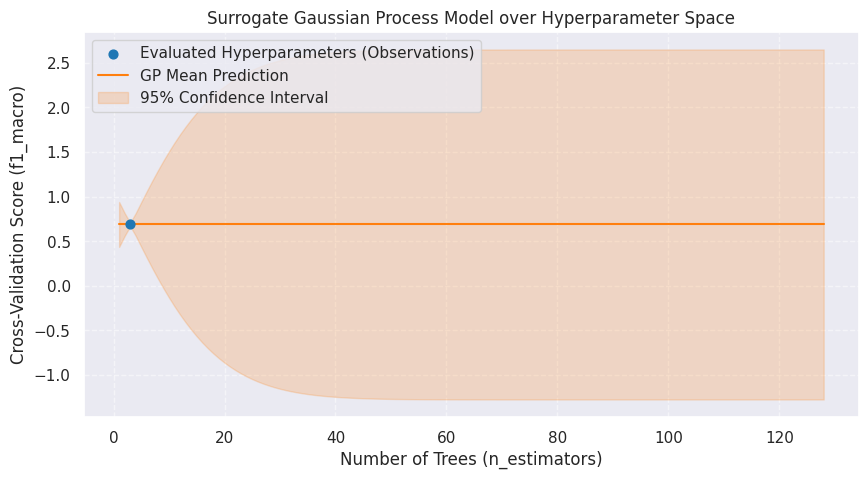

In [23]:
import matplotlib.pyplot as plt

# 1. Generate predictions over your entire hyperparameter search space
mean_pred, std_pred = gpr.predict(X_opt, return_std=True)

# Flatten your collected search points so matplotlib can plot them
x_observed = np.array(X_bo).ravel()
y_observed = np.array(y_bo)

plt.figure(figsize=(10, 5))

# Plot your actual cross-validation history points
plt.scatter(
    x_observed,
    y_observed,
    color="tab:blue",
    marker="o",
    s=40,
    zorder=5,
    label="Evaluated Hyperparameters (Observations)",
)

# Connect them chronologically with a light dotted line to see the search path
plt.plot(x_observed, y_observed, linestyle="dotted", color="tab:blue", alpha=0.5)

# Plot the surrogate model's predicted performance mean curve
plt.plot(X_opt.ravel(), mean_pred, color="tab:orange", label="GP Mean Prediction")

# Shaded 95% Confidence Interval region (Mean +/- 1.96 * Std Dev)
plt.fill_between(
    X_opt.ravel(),
    mean_pred - 1.96 * std_pred,
    mean_pred + 1.96 * std_pred,
    color="tab:orange",
    alpha=0.2,
    label="95% Confidence Interval",
)

plt.legend()
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Cross-Validation Score (f1_macro)")
plt.title("Surrogate Gaussian Process Model over Hyperparameter Space")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [24]:
import optuna
from optuna.samplers import RandomSampler, GPSampler, GridSampler, QMCSampler, BruteForceSampler
import warnings
import optuna

optuna.logging.set_verbosity(optuna.logging.ERROR)

warnings.filterwarnings("ignore")

def objective(trial):
  n_estimators = trial.suggest_int("n_estimators", 1, 64)
  max_depth = trial.suggest_int("max_depth", 1, 10)
  max_features = trial.suggest_int("max_features", 1, 6)

  clf = RandomForestClassifier(max_depth=max_depth, n_estimators=n_estimators, max_features=max_features, random_state=42)
  cvs = cross_val_score(clf, X, y, groups=groups, cv=LeaveOneGroupOut(), scoring="f1_macro")

  return cvs.mean()


rs  = RandomSampler(seed=42)

sampler = rs
study = optuna.create_study(sampler=sampler, direction="maximize")
study.optimize(objective, n_trials=100)

best_trial = study.best_trial
print("Best value: ", best_trial.value)
print("Parameters that achieve the best value: ", best_trial.params)



Best value:  0.7488481684285311
Parameters that achieve the best value:  {'n_estimators': 41, 'max_depth': 6, 'max_features': 1}


In [25]:
gp  = GPSampler(seed=42)

sampler = gp
study = optuna.create_study(sampler=sampler, direction="maximize")
study.optimize(objective, n_trials=100)

best_trial = study.best_trial
print("Best value: ", best_trial.value)
print("Parameters that achieve the best value: ", best_trial.params)

Best value:  0.7498009903942576
Parameters that achieve the best value:  {'n_estimators': 31, 'max_depth': 6, 'max_features': 1}


In [26]:
gd  = GridSampler(
  search_space={
    "n_estimators": [1, 32, 64],
    "max_depth": [1, 5, 10],
    "max_features": [1, 3, 6]
  },
  seed=42
)

sampler = gd
study = optuna.create_study(sampler=sampler, direction="maximize")
study.optimize(objective, n_trials=100)

best_trial = study.best_trial
print("Best value: ", best_trial.value)
print("Parameters that achieve the best value: ", best_trial.params)

KeyboardInterrupt: 

In [ ]:
qmc = QMCSampler(seed=42)

sampler = qmc
study = optuna.create_study(sampler=sampler, direction="maximize")
study.optimize(objective, n_trials=100)

best_trial = study.best_trial
print("Best value: ", best_trial.value)
print("Parameters that achieve the best value: ", best_trial.params)

Best value:  0.8067330864434576
Parameters that achieve the best value:  {'n_estimators': 12, 'max_depth': 4, 'max_features': 3}


In [ ]:
bf  = BruteForceSampler(seed=42)

sampler = bf
study = optuna.create_study(sampler=sampler, direction="maximize")
study.optimize(objective, n_trials=100)

best_trial = study.best_trial
print("Best value: ", best_trial.value)
print("Parameters that achieve the best value: ", best_trial.params)

Best value:  0.7970509220035534
Parameters that achieve the best value:  {'n_estimators': 49, 'max_depth': 9, 'max_features': 1}
